In [1]:
import h5py
import numpy as np
import shutil
from datetime import datetime
import sys
import os
import matplotlib.pyplot as plt
import corner
import numpy as np

script_dir = os.path.abspath('/Users/cfy7qw/Documents/uva_hw/comp_astr/')
if script_dir not in sys.path:
    sys.path.append(script_dir)
%load_ext autoreload
%autoreload 2 

import kernels, modeling, plotting,  correction, file_formatting;
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import median_filter
from scipy.ndimage import generic_filter

/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Wavelength ($\mu$m)")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Wavelength ($\mu$m)")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:154: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title(f"Combined GP Analysis: {date} | $\chi^2_\\nu$: {chi2_red:.3f}")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:271: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title(f"Visit Analysis: {date} | $\chi^2_\\nu$: {chi2_red:.3f}")
/Users/cfy7qw/Documents/uva_hw/comp_astr/file_formatting.py:37: SyntaxWarning: invalid escape sequence '\m'
  w_bounds = label.replace('$\mu$m', '').strip().split('-')


In [2]:
obj_name = "PSO318"
instrument = "G235H"

all_mjds = []
all_flux_data = []
h5_files = [
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-11-06/2025-11-06_combined_SpecData.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-21/2025-10-21_combined_SpecData.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-01/2025-10-01_combined_SpecData.h5'
]
for f in h5_files:
    with h5py.File(f, 'r') as h5:
        all_mjds.append(h5['time'][:])
        all_flux_data.append(h5['calibrated_optspec'][:])

global_min_mjd = np.nanmin([np.nanmin(m) for m in all_mjds])
# Define colors: [Color 1, Neutral Midpoint, Color 2]
colors = ["#c22267", "#ffffff", "#1d67e0"] 
custom_cmap = LinearSegmentedColormap.from_list("my_diverging", colors)

In [5]:
class JWSTVisit:
    def __init__(self, date, h5_path):
        self.date = date
        self.h5_path = h5_path
        
        with h5py.File(h5_path, 'r') as hf:
            self.wave_1d = hf['wave_1d'][:]
            self.time_raw = hf['time'][:]
            self.flux_2d_raw = hf['calibrated_optspec'][:]
            self.err_2d_raw = hf['calibrated_opterr'][:]
            
        # 1. White Light Curve
        w_flux_raw = np.nansum(self.flux_2d_raw, axis=1)
        w_err_raw = np.sqrt(np.nansum(self.err_2d_raw**2, axis=1))
        
        # 2. Time Mask
        self.time_mask = np.isfinite(w_flux_raw) & (w_flux_raw > 0)
        
        # 3. Apply mask to everything
        self.time = self.time_raw[self.time_mask]*24  # Convert to hours
        
        norm_val = np.nanmedian(w_flux_raw[self.time_mask])
        self.white_flux = w_flux_raw[self.time_mask] / norm_val
        self.white_error = w_err_raw[self.time_mask] / norm_val
        
        # CRITICAL: Mask the 2D arrays so they match the length of self.time
        self.flux_2d = self.flux_2d_raw[self.time_mask, :]
        self.err_2d = self.err_2d_raw[self.time_mask, :]

    def __repr__(self):
        return f"JWSTVisit({self.date}, points={len(self.time)})"

# --- Setup your visits ---
visits = [
    JWSTVisit('2025-10-01', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-01/2025-10-01_combined_SpecData.h5'),
    JWSTVisit('2025-10-21', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-21/2025-10-21_combined_SpecData.h5'),
    JWSTVisit('2025-11-06', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-11-06/2025-11-06_combined_SpecData.h5')
]

In [27]:
class JWSTVisit:
    def __init__(self, date, h5_path, global_mjd_min=global_min_mjd):
        self.date = date
        self.h5_path = h5_path
        self.global_mjd_min = global_mjd_min

        with h5py.File(h5_path, 'r') as hf:
            wave_raw = hf['wave_1d'][:]
            time_raw = hf['time'][:] # Assumed to be in MJD
            flux_2d_raw = hf['calibrated_optspec'][:]
            err_2d_raw = hf['calibrated_opterr'][:]
            
        # 1. Sort by time
        sort_idx = np.argsort(time_raw)
        time_raw = time_raw[sort_idx]
        flux_2d_raw = flux_2d_raw[sort_idx, :]
        err_2d_raw = err_2d_raw[sort_idx, :]

        # 2. White Light Curve
        w_flux_raw = np.nansum(flux_2d_raw, axis=1)
        w_err_raw = np.sqrt(np.nansum(err_2d_raw**2, axis=1))
        
        # 3. Create Time Mask
        self.time_mask = np.isfinite(w_flux_raw) & (w_flux_raw > 0)
        
        # 4. Global Unit Conversion (Hours relative to first observation)
        # Subtracting global_mjd_min ensures Visit 1 starts at 0, 
        # while later visits correctly represent the elapsed hours since then.
        raw_masked_time = time_raw[self.time_mask]
        self.time = (raw_masked_time - global_mjd_min) * 24.0
        
        # 5. Store Masked Data
        self.wave_1d = wave_raw
        norm_val = np.nanmedian(w_flux_raw[self.time_mask])
        self.white_flux = w_flux_raw[self.time_mask] / norm_val
        self.eureka_error = w_err_raw[self.time_mask] / norm_val
        self.flux_2d = flux_2d_raw[self.time_mask, :]
        self.err_2d = err_2d_raw[self.time_mask, :]

        # Build trend
        lc_trend = median_filter(self.white_flux, size=5)

        # Residuals
        residuals = self.white_flux - lc_trend

        # Empirical noise
        scatter = np.nanstd(residuals)
        self.white_error = np.full_like(self.white_flux, scatter)

visits = [
    JWSTVisit('2025-10-01', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-01/2025-10-01_combined_SpecData.h5'),
    JWSTVisit('2025-10-21', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-21/2025-10-21_combined_SpecData.h5'),
    JWSTVisit('2025-11-06', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-11-06/2025-11-06_combined_SpecData.h5')
]


--- Processing Visit: 2025-10-01 ---


  0%|          | 0/600 [00:00<?, ?it/s]/opt/anaconda3/envs/eureka2/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 600/600 [00:01<00:00, 308.15it/s]


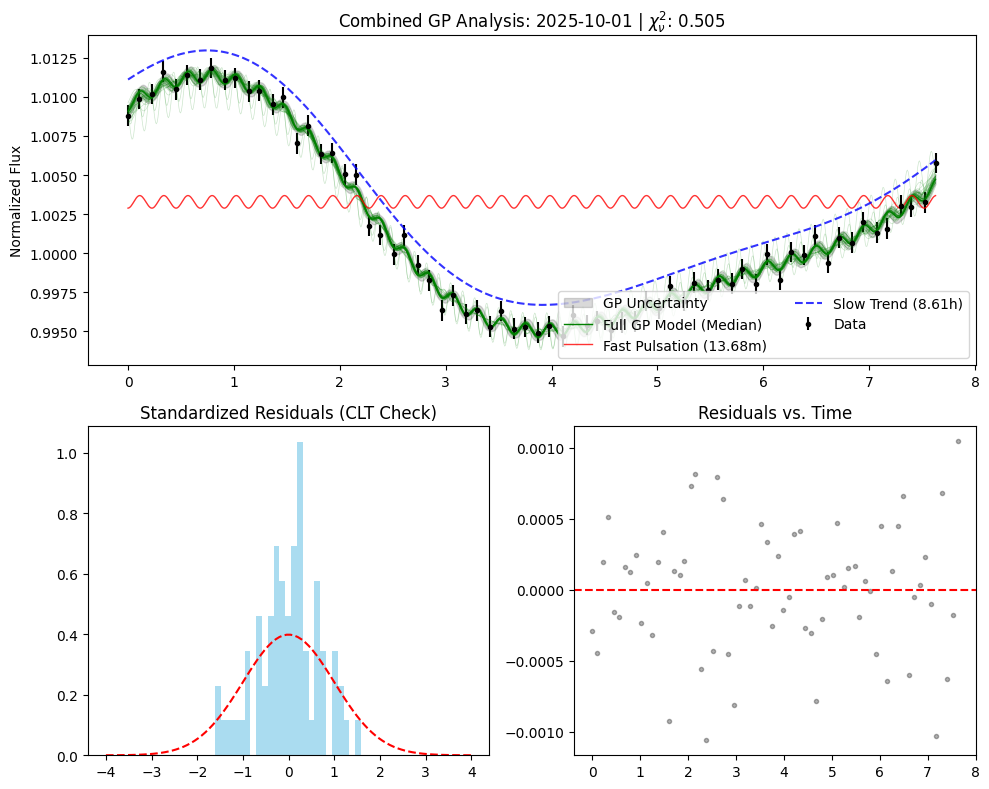


--- 2025-10-01 FINAL SUMMARY ---
Fast Period: 13.6761 min
Slow Period: 8.6076 hours
Chi-Squared Red: 0.5052 (Taller histogram = Overestimated Errors)


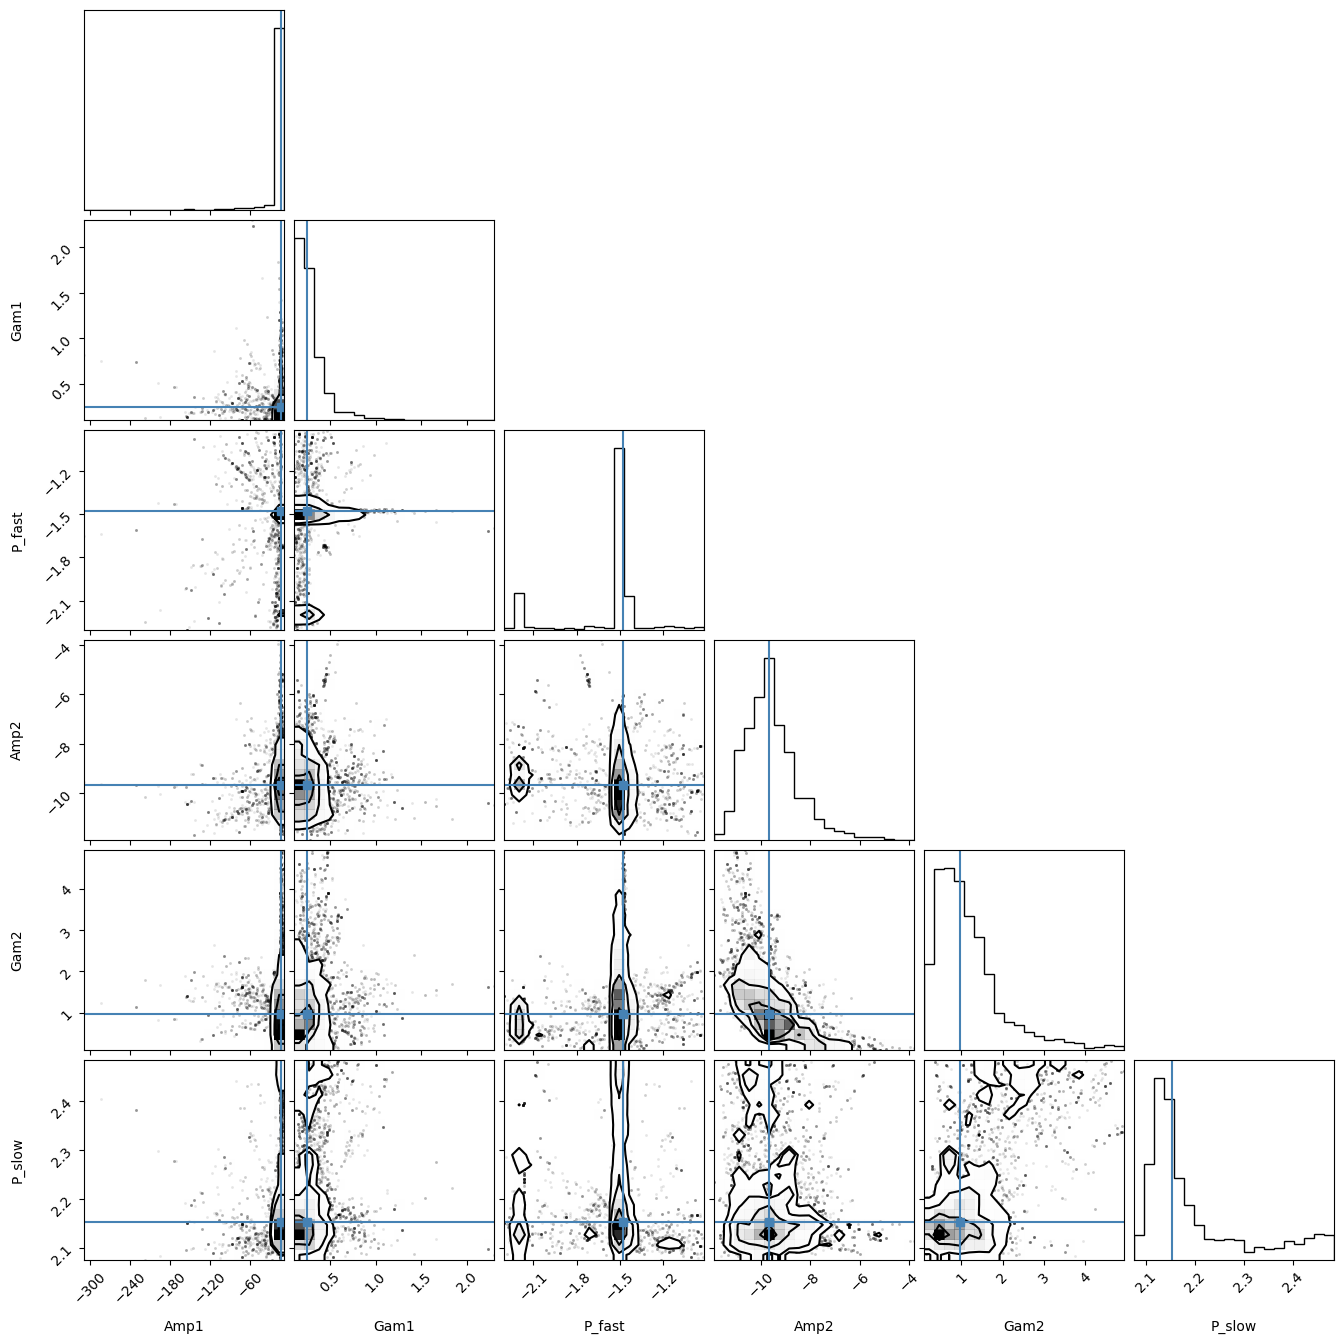


--- Processing Visit: 2025-10-21 ---


100%|██████████| 600/600 [00:01<00:00, 316.72it/s]


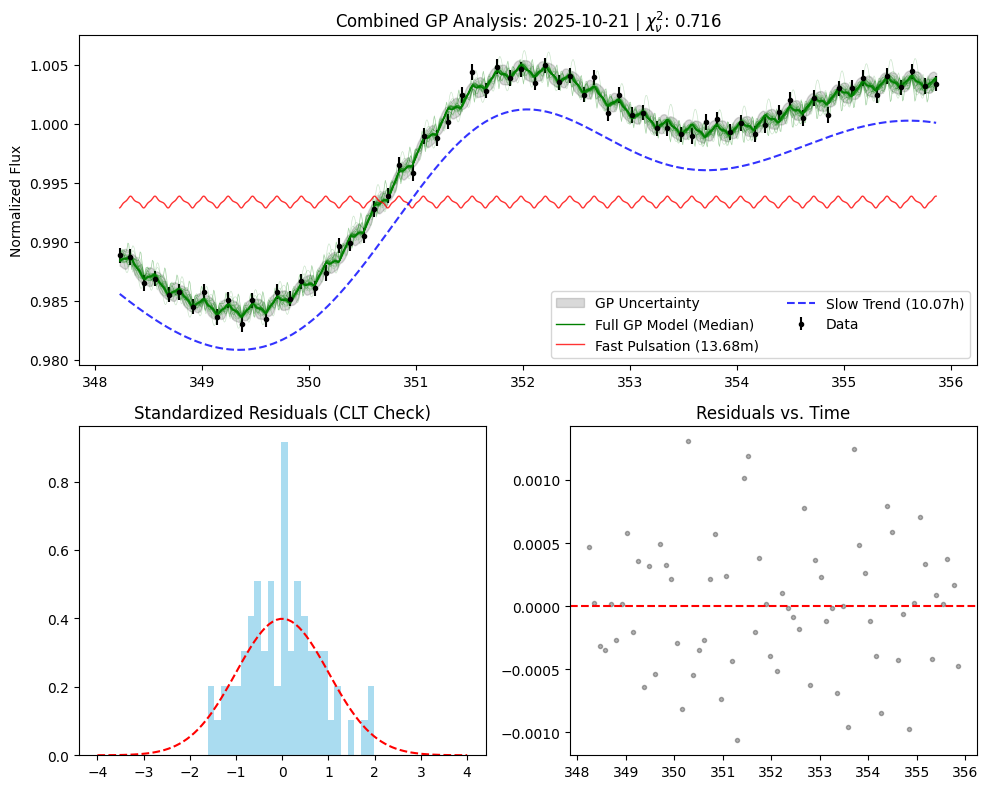


--- 2025-10-21 FINAL SUMMARY ---
Fast Period: 13.6787 min
Slow Period: 10.0651 hours
Chi-Squared Red: 0.7158 (Taller histogram = Overestimated Errors)


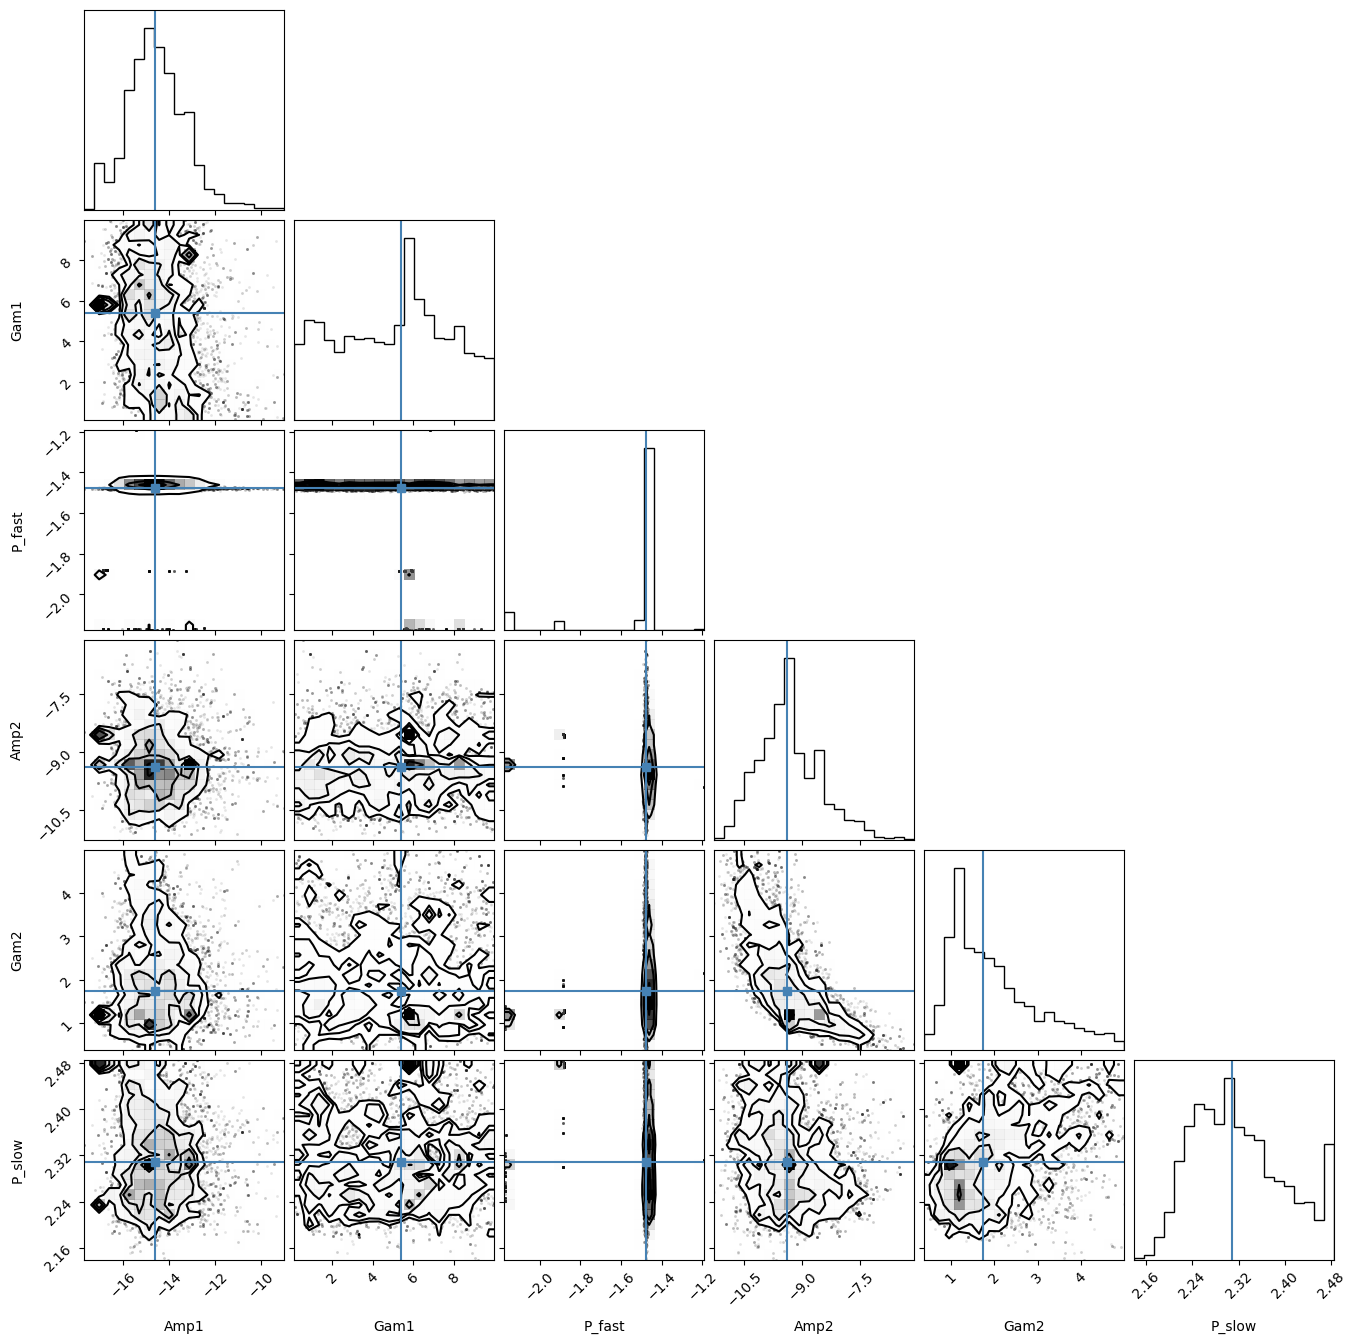


--- Processing Visit: 2025-11-06 ---


  0%|          | 0/600 [00:00<?, ?it/s]/opt/anaconda3/envs/eureka2/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 600/600 [00:01<00:00, 326.93it/s]


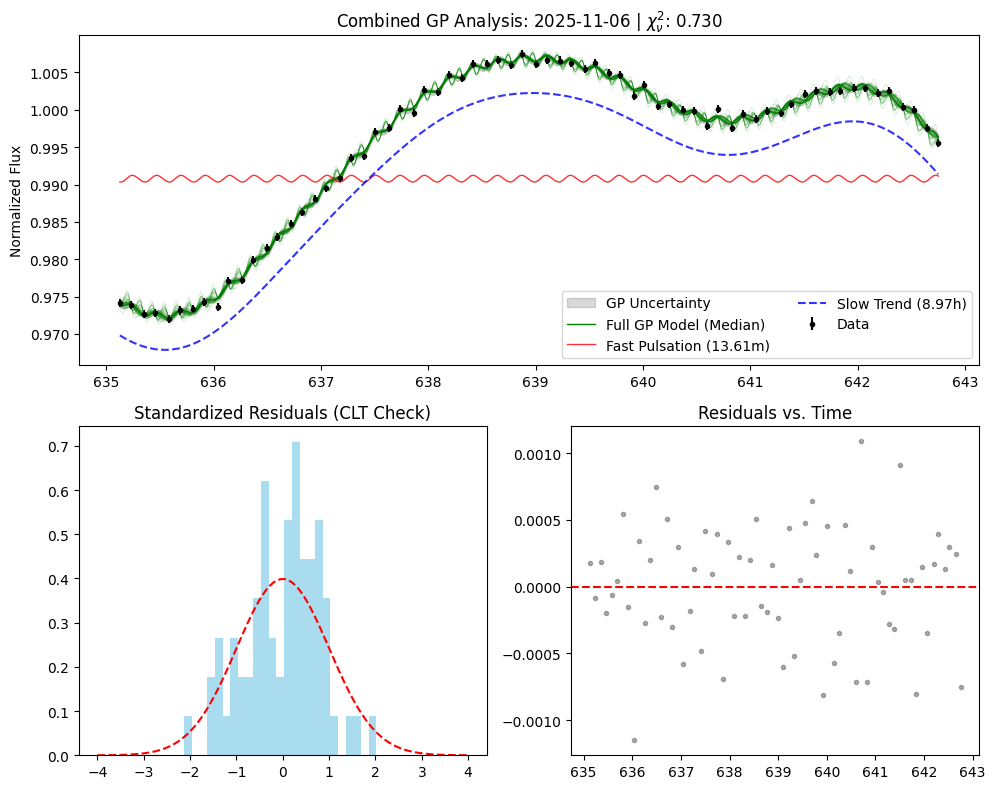


--- 2025-11-06 FINAL SUMMARY ---
Fast Period: 13.6082 min
Slow Period: 8.9688 hours
Chi-Squared Red: 0.7298 (Taller histogram = Overestimated Errors)


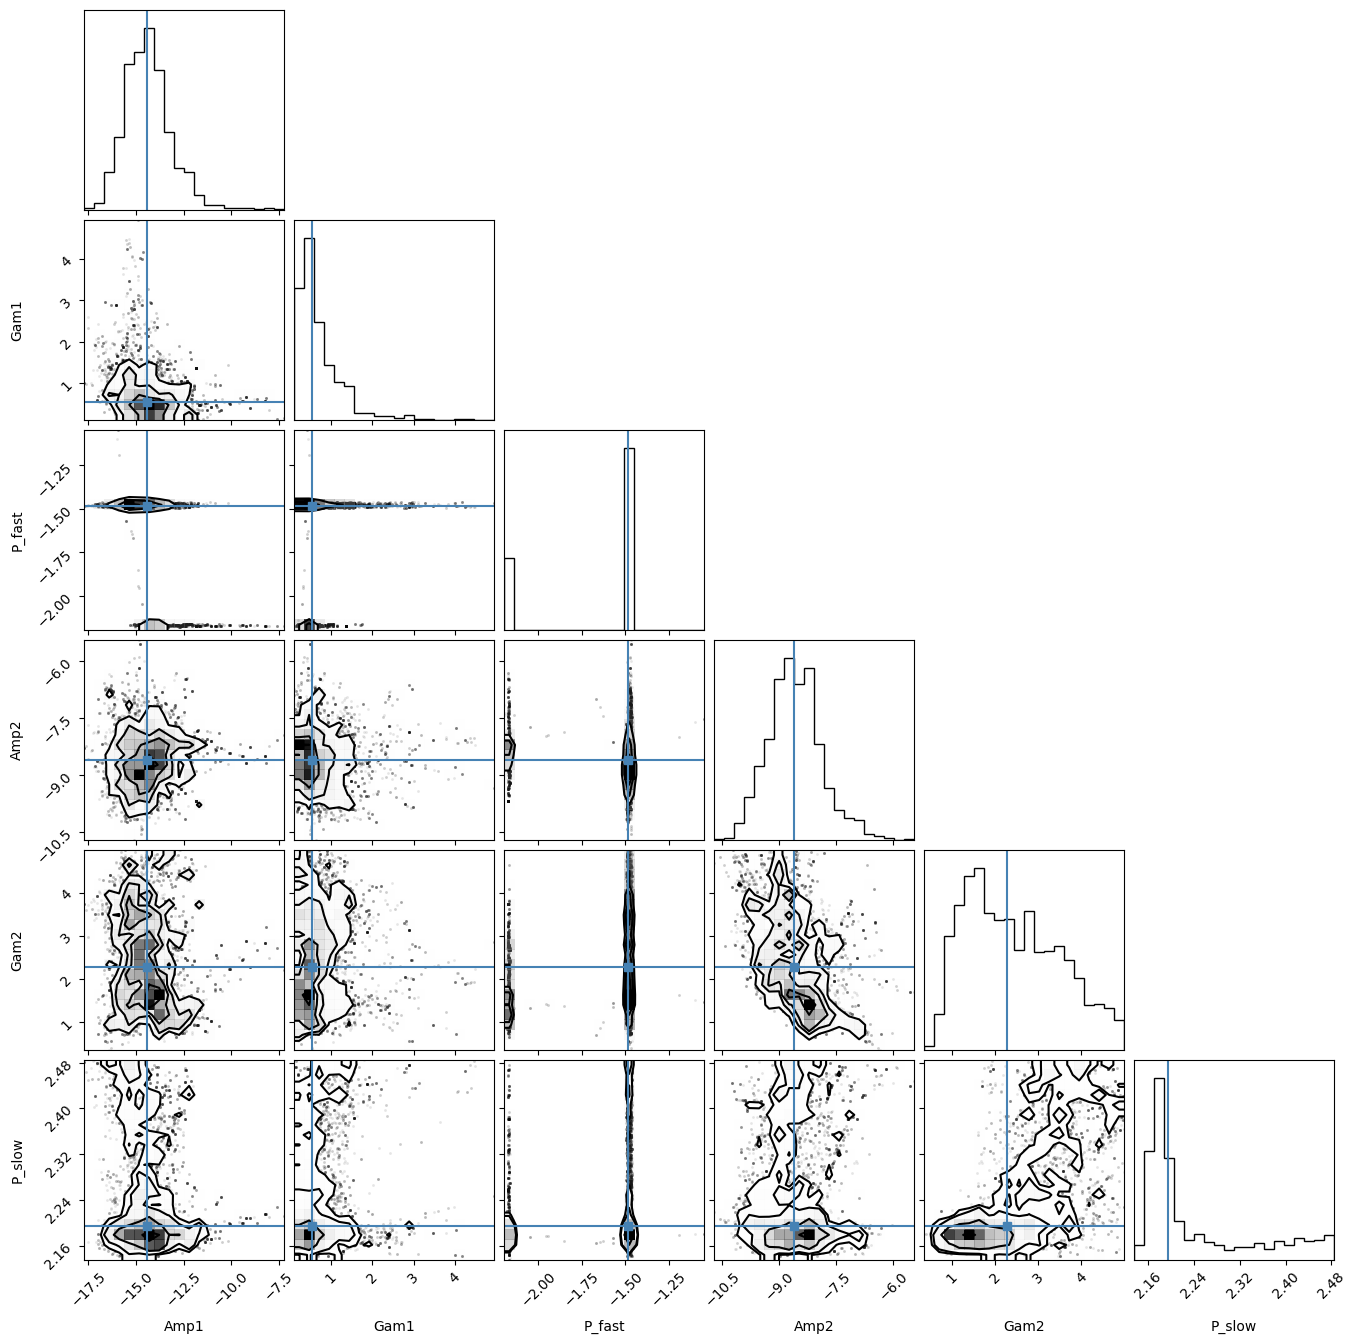

In [ ]:
for v in visits:
    print(f"\n--- Processing Visit: {v.date} ---")
    
    # 1. GP & MCMC Setup
    # Your time is now already sorted and in relative hours from the class
    gp_obj, kf, ks = kernels.get_kernel(v.time, v.white_flux, v.white_error, 0.2, 8.0)
    
    bounds = [
        (None, None), (0.1, 10.0), (np.log(0.1), np.log(0.4)), # Fast
        (None, None), (0.1, 5.0),  (np.log(4.0), np.log(12.0)) # Slow
    ]
    
    samples, mcmc_results, res = modeling.run_mcmc(v.time, v.white_flux, gp_obj, bounds)

    # 2. Extract Best-Fit Parameters and Shaded Uncertainty
    x_pred, mu, gp_std, mu_f, mu_s, residuals, mcmc_mu_samples = modeling.get_best_params(
        gp_obj, v.time, v.white_flux, samples, mcmc_results, kf, ks
    )

    all_waves = v.wave_1d
    entire_range = [(all_waves[0], all_waves[-1])]
    
    binned_results = correction.run_binned_analysis(
    v.time,
    v.flux_2d,
    v.err_2d,
    v.wave_1d,
    gp_obj,
    mcmc_results,
    kf,
    ks,
    wav_ranges=entire_range
)
    pixel_data = correction.get_corrected_pixel_data(
    v.h5_path,
    binned_results
)
    
    # 5. Extract Corrected Pixels and Save
    #pixel_data = correction.get_corrected_pixel_data(v.h5_path, binned_results)
    
    # Plotting & Exports
    plotting.plot_results(v.time, v.white_flux, v.white_error, x_pred, mu, gp_std, mu_f, mu_s, residuals, samples, mcmc_results, mcmc_mu_samples, v.date)
    # plotting.plot_correction_diagnostics(v, binned_results, pixel_data)
    final_output_path = v.h5_path.replace(".h5", "_GP_corrected.h5")
    #file_formatting.save_corr_data(v.h5_path, pixel_data, final_output_path)

In [24]:
import h5py
import numpy as np

# Path to one of your PSO318 Eureka! Stage 3 output files
file_path = '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-01/2025-10-01_combined_SpecData_GP_corrected.h5'

def inspect_h5_file(path):
    print(f"--- Inspecting File: {path.split('/')[-1]} ---")
    with h5py.File(path, 'r') as hf:
        # Standard table header
        print(f"{'Dataset Name':<25} | {'Shape':<15} | {'Dtype':<10}")
        print("-" * 55)
        
        for key in hf.keys():
            data = hf[key]
            # Check if it's a dataset (not a group)
            if isinstance(data, h5py.Dataset):
                shape_str = str(data.shape)
                dtype_str = str(data.dtype)
                print(f"{key:<25} | {shape_str:<15} | {dtype_str:<10}")

# Run the inspection
inspect_h5_file(file_path)

--- Inspecting File: 2025-10-01_combined_SpecData_GP_corrected.h5 ---
Dataset Name              | Shape           | Dtype     
-------------------------------------------------------
calibrated_opterr         | (68, 3472)      | float64   
calibrated_optspec        | (68, 3472)      | float64   
centroid_sy               | (68,)           | float64   
centroid_y                | (68,)           | float64   
div_err_norm              | ()              | float64   
err_2d_gp_corrected       | (68, 3472)      | float64   
flux_2d_gp_corrected      | (68, 3472)      | float32   
master_calibration_factors | (3472,)         | float64   
medflux                   | (29, 3472)      | float64   
opterr                    | (68, 3472)      | float32   
optmask                   | (68, 3472)      | int8      
optspec                   | (68, 3472)      | float32   
raw_err_norm              | ()              | float64   
skyerr                    | (68, 3472)      | float64   
skylev            

# 2d flux arrays

<>:94: SyntaxWarning: invalid escape sequence '\m'
<>:94: SyntaxWarning: invalid escape sequence '\m'
/var/folders/jd/81hzh9jn56gf9hxgftx67y200000gp/T/ipykernel_52837/2520106973.py:94: SyntaxWarning: invalid escape sequence '\m'
  axes[-1].set_xlabel('Wavelength [$\mu$m]', fontsize=15)
/var/folders/jd/81hzh9jn56gf9hxgftx67y200000gp/T/ipykernel_52837/2520106973.py:33: RuntimeWarning: All-NaN slice encountered
  col_medians = np.nanmedian(flux_sorted, axis=0)


(68, 3472) [np.float32(1.6314219), np.float32(3.0716054), np.float64(635.1266868998646), np.float64(642.7516667182208)]
(68, 3472) [np.float32(1.6313379), np.float32(3.0715322), np.float64(348.2330725901993), np.float64(355.86020357441157)]
(68, 3472) [np.float32(1.6313872), np.float32(3.0716333), np.float64(0.0), np.float64(7.627151497872546)]


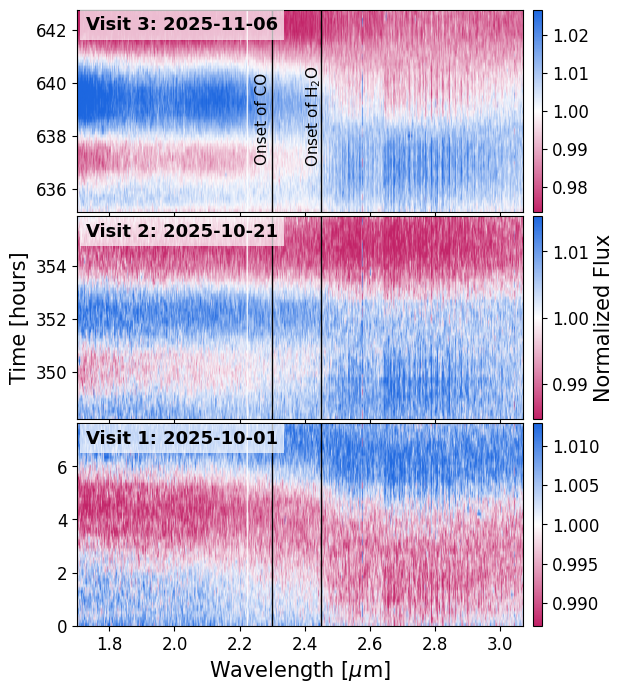

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
h5_files = [
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-11-06/2025-11-06_combined_SpecData_GP_corrected.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-21/2025-10-21_combined_SpecData_GP_corrected.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-01/2025-10-01_combined_SpecData_GP_corrected.h5'
]

fig, axes = plt.subplots(len(h5_files), 1, figsize=(6, 8),sharex=True)
plt.subplots_adjust(hspace=0.02)

for i, f_path in enumerate(h5_files):
    ax = axes[i]
    
    # Load data
    with h5py.File(f_path, 'r') as h5:
        wave = h5['wave_1d'][:]
        time_raw = h5['time'][:] 
        flux_raw = h5['calibrated_optspec'][:]
        flux_new=h5['flux_2d_gp_corrected'][:]
    flux_diff = (flux_new-flux_raw)
    
    # --- SORTING & TIME CONVERSION ---
    sort_idx = np.argsort(time_raw)
    time_sorted = time_raw[sort_idx]
    flux_sorted = flux_new[sort_idx, :]
    time_hours = (time_sorted - global_min_mjd) * 24

    # --- PER-VISIT NORMALIZATION (Column-wise) ---
    col_medians = np.nanmedian(flux_sorted, axis=0)
    col_medians[col_medians == 0] = np.nan
    norm_flux_2d = flux_sorted / col_medians
    
    # Smooth slightly for visualization
    plot_data = gaussian_filter(np.nan_to_num(norm_flux_2d, nan=1.0), sigma=0.8)

    # --- CALCULATE 90% RANGE LIMITS (Symmetric around 1.0) ---
    v_low = np.nanpercentile(plot_data, 5)
    v_high = np.nanpercentile(plot_data, 95)
    dist = max(abs(1.0 - v_low), abs(1.0 - v_high))
    dist = max(dist, 0.005) 
    v_min, v_max = 1.0 - dist, 1.0 + dist


    # X-axis: Wavelength | Y-axis: Time
    # Extent order: [left, right, bottom, top]
    t_start, t_end = time_hours.min(), time_hours.max()
    extents = [wave.min(), wave.max(), t_start, t_end] 
    
    im = ax.imshow(plot_data, aspect='auto', extent=extents, 
                    cmap=custom_cmap, vmin=v_min, vmax=v_max)
    print(plot_data.shape, extents)
    

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)

    if i==1:
        ax.set_ylabel('Time [hours]', fontsize=15)
    if i==1:
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('Normalized Flux', size=15)
        cbar.ax.tick_params(labelsize=12)
    else:
        cbar = plt.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=12)
    ax.set_xlim(wave.min()+0.069, wave.max())
    visit_label = f_path.split('/')[-2]
    ax.text(0.02, 0.9, f"Visit {3-i}: {visit_label}", transform=ax.transAxes, 
                 fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='None'), fontsize=13,color='k')
    
    ax.axvline(2.45, color='k',linewidth=1)
    ax.axvline(2.3, color='k',linewidth=1)
    if i==0:
        ax.text(.51, 0.25, r"Onset of H$_2$O", transform=ax.transAxes,fontsize=11, rotation=90,color='k')
        ax.text(.4, 0.25, r"Onset of CO", transform=ax.transAxes,fontsize=11, rotation=90,color='k')
    ax.tick_params(axis='both', which='major', labelsize=12)
    rotation_period = 7.8

    first_rot = np.ceil(t_start / rotation_period) * rotation_period

    rot_times = np.arange(first_rot, t_end, rotation_period)

    # for rt in rot_times:
    #     ax.axhline(rt, linestyle='--', color='k',linewidth=1.5, alpha=1.0)
   #ax.set_title(f"Visit: {visit_label}", fontweight='bold', loc='left')
    
    # ax.axvline(2.459, color='black', linestyle=':', alpha=0.5)

# Global X-Label
axes[-1].set_xlabel('Wavelength [$\mu$m]', fontsize=15)
plt.show()

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
/var/folders/jd/81hzh9jn56gf9hxgftx67y200000gp/T/ipykernel_67979/695060815.py:86: SyntaxWarning: invalid escape sequence '\m'
  axes[-1, 0].set_xlabel('Wavelength ($\mu$m)', fontsize=15)
/var/folders/jd/81hzh9jn56gf9hxgftx67y200000gp/T/ipykernel_67979/695060815.py:13: RuntimeWarning: All-NaN slice encountered
  global_wave_medians = np.nanmedian(combined_flux, axis=0)


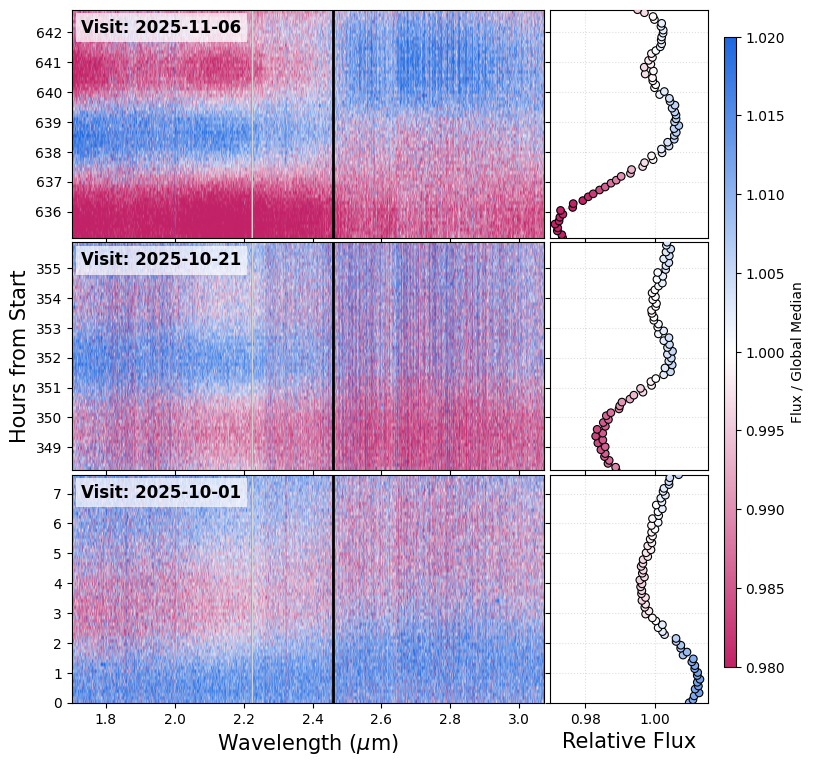

In [114]:
# Define colors: [Color 1, Neutral Midpoint, Color 2]
colors = ["#c22267", "#ffffff", "#1d67e0"] 
custom_cmap = LinearSegmentedColormap.from_list("my_diverging", colors)

h5_files = [
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-11-06/2025-11-06_combined_SpecData_GP_corrected.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-21/2025-10-21_combined_SpecData_GP_corrected.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-01/2025-10-01_combined_SpecData_GP_corrected.h5'
]

# The Global Normalization baselines
combined_flux = np.concatenate(all_flux_data, axis=0)
global_wave_medians = np.nanmedian(combined_flux, axis=0)
global_sum_median = np.nanmedian(np.nansum(combined_flux, axis=1))

# --- 2. SETUP PLOT ---
fig, axes = plt.subplots(len(h5_files), 2, figsize=(8, 9), 
                         sharex='col', sharey='row',
                         gridspec_kw={'width_ratios': [3, 1]})

plt.subplots_adjust(hspace=0.02, wspace=0.02, right=0.92)

v_min, v_max = 0.98, 1.02
cmap_name = custom_cmap

for i, f_path in enumerate(h5_files):
    ax_heat = axes[i, 0]
    ax_lc = axes[i, 1]
    
    with h5py.File(f_path, 'r') as h5:
        wave = h5['wave_1d'][:]
        time_raw = h5['time'][:] 
        flux_raw = h5['calibrated_optspec'][:]
        flux_new=h5['flux_2d_gp_corrected'][:]
    flux_diff = (flux_new-flux_raw)
    # --- SORTING ---
    sort_idx = np.argsort(time_raw)
    time_sorted = time_raw[sort_idx]
    flux_sorted = flux_raw[sort_idx, :]

    # --- TIME CONVERSION: MJD -> Hours since first observation ---
    # (Current MJD - Global Minimum) * 24 hours/day
    time_hours = (time_sorted - global_min_mjd) * 24

    # --- NORMALIZATION ---
    norm_flux_2d = flux_sorted / global_wave_medians
    plot_data = gaussian_filter(norm_flux_2d, sigma=.0)
    
    total_flux_1d = np.nansum(flux_sorted, axis=1)
    lc_norm = total_flux_1d / global_sum_median

    # --- PLOT HEATMAP ---
    t_start, t_end = time_hours.min(), time_hours.max()
    # Extent: [left, right, bottom, top] -> [wave_min, wave_max, Max_Hours, Min_Hours]
    extents = [wave.min(), wave.max(), t_end, t_start]
    
    im = ax_heat.imshow(plot_data, aspect='auto', extent=extents, 
                        cmap=cmap_name, vmin=v_min, vmax=v_max)
    
    # --- PLOT LIGHT CURVE ---
    ax_lc.plot(lc_norm, time_hours, color='gray', lw=0.8, alpha=0.3)
    ax_lc.scatter(lc_norm, time_hours, c=lc_norm, 
                  cmap=cmap_name, vmin=v_min, vmax=v_max, 
                  s=30, edgecolor='k', linewidth=0.8, zorder=3)
    

    # --- AXIS SYNC & ORIENTATION ---
    # Put earlier hours at the top
    ax_heat.set_ylim(t_start, t_end)
    ax_heat.set_xlim(wave.min()+0.069, wave.max())
    ax_heat.axvline(2.459, color='black', linestyle='-', lw=2)
    ax_lc.set_ylim(t_start, t_end)
    
    # Unified X-limits for the light curve
    ax_lc.set_xlim(0.97, 1.015)
    
    # Labeling
    visit_label = f_path.split('/')[-2] # Assumes date is the folder name
    if i==1:
        ax_heat.set_ylabel('Hours from Start', fontsize=15)
    ax_heat.text(0.02, 0.9, f"Visit: {visit_label}", transform=ax_heat.transAxes, 
                 fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'), fontsize=12)
    ax_lc.grid(True, linestyle=':', alpha=0.4)

# Global Labels
axes[-1, 0].set_xlabel('Wavelength ($\mu$m)', fontsize=15)
axes[-1, 1].set_xlabel('Relative Flux', fontsize=15)

# Unified Colorbar
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Flux / Global Median')

#plt.suptitle(f"Time-Resolved Variability: {obj_name}", fontsize=18, y=0.96)
plt.show()

/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:38: RuntimeWarning: All-NaN slice encountered
  raw_spec = np.nanmedian(v.flux_2d, axis=0) # Median over time
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:48: RuntimeWarning: All-NaN slice encountered
  all_corr_flux.append(np.nanmedian(data['fluxes'], axis=0))


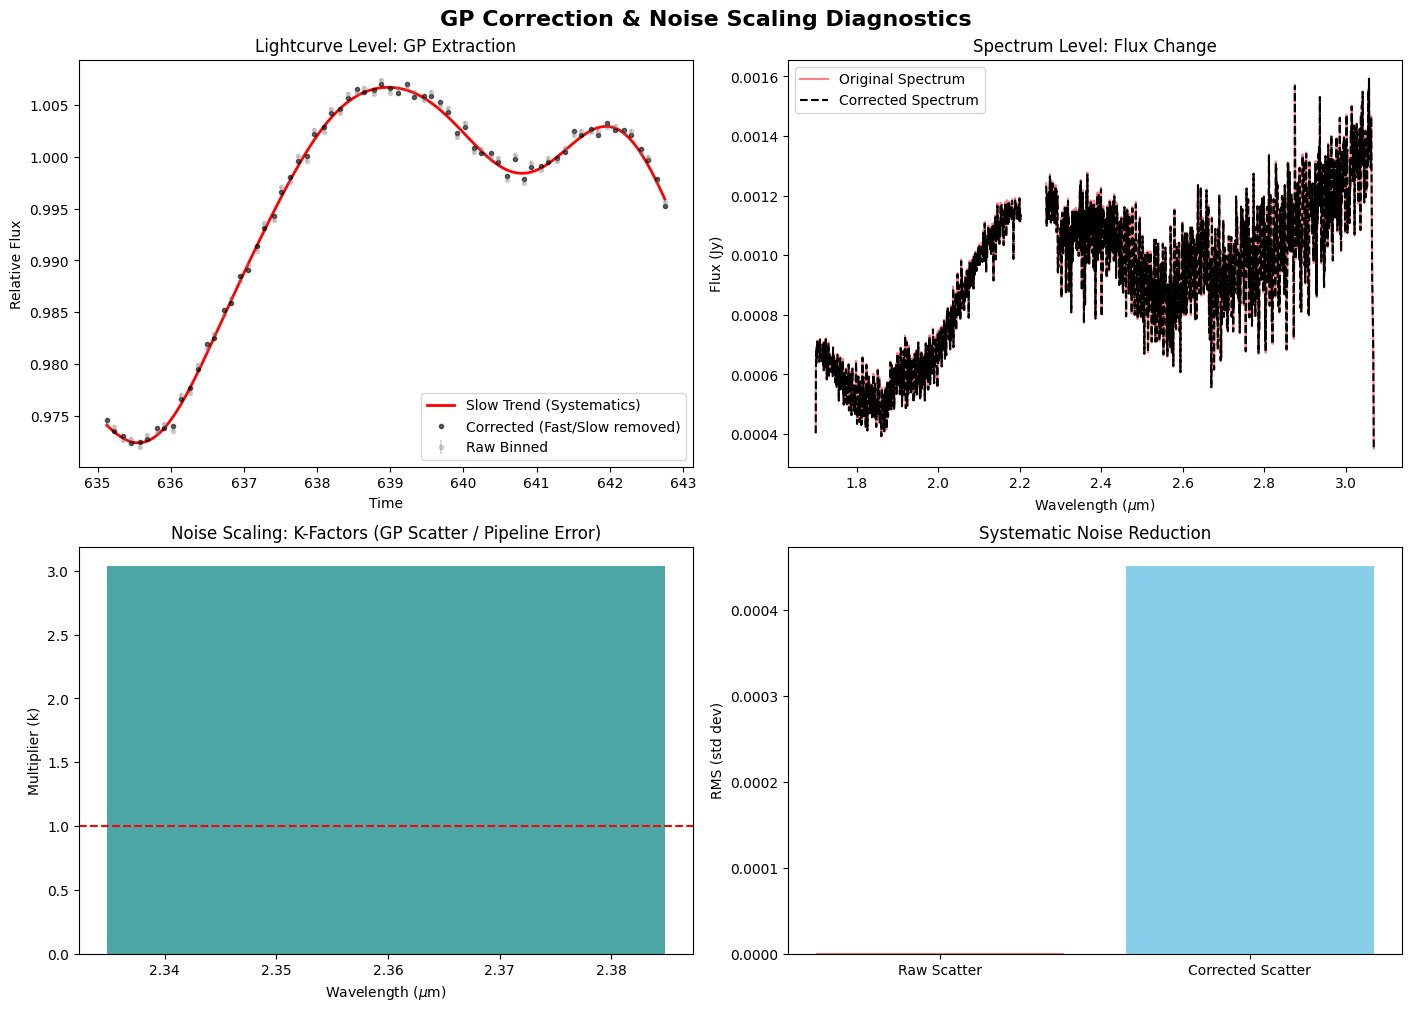